# Exploration - Forest Loss

https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/download.html

## Notes

* Tree cover loss is not always deforestation. 

In [1]:
### Step 0 – Libraries and paths ###

import geopandas as gpd
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
from pathlib import Path
import pandas as pd
from rasterstats import zonal_stats
import matplotlib.pyplot as plt

In [2]:
# folder with the four Hansen lossyear tiles
loss_dir = Path(r"../data/input/global-forest-change-hansen")

# admin1 shapefile
admin1_path = Path(r"../data/input/cmr_admin_boundaries_humdata/cmr_admin1.shp")

# where to save intermediate rasters
out_dir = Path(r"../data/output/intermediate-rasters")
out_dir.mkdir(exist_ok=True, parents=True)

In [3]:
### Step 1a – Mosaic the 4 lossyear tiles ###

loss_paths = sorted(loss_dir.glob("Hansen_GFC-2024-v1.12_lossyear_*.tif"))
if not loss_paths:
    raise FileNotFoundError(f"No lossyear tiles found in: {loss_dir}")

# Open all rasters
srcs = [rasterio.open(p) for p in loss_paths] 

try:
    # Limit merge extent to Cameroon bounds (in raster CRS) to avoid huge memory allocation
    admin1 = gpd.read_file(admin1_path).to_crs(srcs[0].crs)
    cameroon_bounds = tuple(admin1.total_bounds)  # (minx, miny, maxx, maxy)

    # Merge rasters, limiting to Cameroon bounds
    mosaic, mosaic_transform = merge(srcs, bounds=cameroon_bounds) 
    meta = srcs[0].meta.copy()
    meta.update({
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": mosaic_transform,
        "count": mosaic.shape[0]
    })

    loss_mosaic_path = out_dir / "lossyear_mosaic_cameroon_region.tif"
    with rasterio.open(loss_mosaic_path, "w", **meta) as dst:
        dst.write(mosaic)

# ensure files are closed to free memory
finally:
    for s in srcs:
        s.close()

In [33]:
### Did the same above for the forest cover 2000 ###
### Step 1b – Mosaic the 4 treecover2000 tiles ###

forest_cover_paths = sorted(loss_dir.glob("Hansen_GFC-2024-v1.12_treecover2000_*.tif"))
if not forest_cover_paths:
    raise FileNotFoundError(f"No treecover2000 tiles found in: {loss_dir}")

# Open all rasters
srcs = [rasterio.open(p) for p in forest_cover_paths]

try:
    admin1 = gpd.read_file(admin1_path).to_crs(srcs[0].crs)
    cameroon_bounds = tuple(admin1.total_bounds)
    mosaic, mosaic_transform = merge(srcs, bounds=cameroon_bounds)
    meta = srcs[0].meta.copy()
    meta.update({
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": mosaic_transform,
        "count": mosaic.shape[0]
    })
    forest2000_mosaic_path = out_dir / "treecover2000_mosaic_cameroon_region.tif"
    with rasterio.open(forest2000_mosaic_path, "w", **meta) as dst:
        dst.write(mosaic)

finally:
    for s in srcs:
        s.close()
    

In [34]:
cameroon_bounds

(8.498952800000097, 1.6546659000001114, 16.19214760000017, 13.083333000000152)

In [7]:
### Step 2a – Clip the mosaic to Cameroon (union of Admin1) ###
# This keeps only the part of the lossyear tiles that overlaps Cameroon.

admin1 = gpd.read_file(admin1_path)

with rasterio.open(loss_mosaic_path) as src:
    # reproject admin1 to raster CRS
    admin1 = admin1.to_crs(src.crs)

    # single polygon = union of all regions
    cameroon_geom = [admin1.unary_union]

    loss_clip, loss_clip_transform = mask(src, cameroon_geom, crop=True)
    loss_clip = loss_clip[0]  # first band

    clip_meta = src.meta.copy()
    clip_meta.update({
        "height": loss_clip.shape[0],
        "width": loss_clip.shape[1],
        "transform": loss_clip_transform
    })

loss_clip_path = out_dir / "lossyear_cameroon_clip.tif"
with rasterio.open(loss_clip_path, "w", **clip_meta) as dst:
    dst.write(loss_clip, 1)

C:\Users\Move\AppData\Local\Temp\ipykernel_10552\2582382328.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  cameroon_geom = [admin1.unary_union]


In [35]:
### Step 2b – Clip the treecover2000 mosaic to Cameroon (union of Admin1) ###

with rasterio.open(forest2000_mosaic_path) as src:
    # reproject admin1 to raster CRS
    admin1 = admin1.to_crs(src.crs)

    # single polygon = union of all regions
    cameroon_geom = [admin1.unary_union]

    forest2000_clip, forest2000_clip_transform = mask(src, cameroon_geom, crop=True)
    forest2000_clip = forest2000_clip[0]  # first band

    forest2000_clip_meta = src.meta.copy()
    forest2000_clip_meta.update({
        "height": forest2000_clip.shape[0],
        "width": forest2000_clip.shape[1],
        "transform": forest2000_clip_transform
    })

forest2000_clip_path = out_dir / "treecover2000_cameroon_clip.tif"
with rasterio.open(forest2000_clip_path, "w", **forest2000_clip_meta) as dst:
    dst.write(forest2000_clip, 1)

C:\Users\Move\AppData\Local\Temp\ipykernel_10552\2986469276.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  cameroon_geom = [admin1.unary_union]


In [51]:
import numpy as np

### Step 3 – Zonal histogram with forest2000 filter ###
# Keep lossyear only where forest2000 > forest_cover_threshold; otherwise set lossyear to 0.

forest_cover_threshold = 30  # only consider pixels with >30% tree cover in 2000 as forest


with rasterio.open(loss_clip_path) as loss_src, rasterio.open(forest2000_clip_path) as f2000_src:
    admin1 = admin1.to_crs(loss_src.crs)
    pixel_area_m2 = 30 * 30  # Hansen pixel size

    lossyear = loss_src.read(1)
    forest2000 = f2000_src.read(1)

    if lossyear.shape != forest2000.shape:
        raise ValueError("lossyear and forest2000 rasters do not have the same shape.")

    # Keep only pixels where forest2000 > forest_cover_threshold and lossyear is a valid code (1..24)
    lossyear_filtered = np.where(
        (forest2000 > forest_cover_threshold) & (lossyear >= 1) & (lossyear <= 24),
        lossyear, # keep original lossyear code where condition is met
        0 # set to 0 where condition is not met
    ).astype(lossyear.dtype)

    stats = zonal_stats(
        admin1,
        lossyear_filtered,
        affine=loss_src.transform,
        categorical=True,
        nodata=0
    )

records = []
for region_row, zs in zip(admin1.itertuples(), stats):
    region_name = region_row.adm1_name

    for code, count in zs.items():
        if code == 0:
            continue
        year = 2000 + int(code)
        records.append({
            "region": region_name,
            "year": year,
            "loss_pixels": int(count),
        })

df = pd.DataFrame(records)

# add area in km2
df["loss_area_km2"] = df["loss_pixels"] * pixel_area_m2 / 1e6

# add cumulative loss area per region
df["accumulated_loss_area_km2"] = df.groupby("region")["loss_area_km2"].cumsum() 

### add the number of cells of forestcover2000 > forest_cover_threshold per region as well
forest_cover_stats = zonal_stats(
    admin1,
    (forest2000 > forest_cover_threshold).astype(rasterio.uint8),
    affine=f2000_src.transform,
    stats=["count"],
    nodata=0
)
totals_forest_cover_2000 = pd.DataFrame({
    "region": admin1["adm1_name"].values,
    "forest_cover_2000_cells": [d["count"] for d in forest_cover_stats]
})
totals_forest_cover_2000["forest_cover_2000_area_km2"] = totals_forest_cover_2000["forest_cover_2000_cells"] * pixel_area_m2 / 1e6
df = df.merge(totals_forest_cover_2000, on="region", how="left")

### total raster cells per region ###
cell_stats = zonal_stats(
    admin1,
    forest2000,
    affine=loss_src.transform,
    stats=["count"],
    nodata=0
)

totals = pd.DataFrame({
    "region": admin1["adm1_name"].values,
    "total_cells_region": [d["count"] for d in cell_stats]
})
totals["total_area_km2_region"] = totals["total_cells_region"] * pixel_area_m2 / 1e6

df = df.merge(totals, on="region", how="left")
df = df.sort_values(["region", "year"]).reset_index(drop=True)


In [52]:
df

,region,year,loss_pixels,loss_area_km2,accumulated_loss_area_km2,forest_cover_2000_cells,forest_cover_2000_area_km2,total_cells_region,total_area_km2_region
0,Adamawa,2001,97703,87.9327,87.9327,44704249,40233.8241,83339520,75005.5680
1,Adamawa,2002,44927,40.4343,128.3670,44704249,40233.8241,83339520,75005.5680
2,Adamawa,2003,38507,34.6563,163.0233,44704249,40233.8241,83339520,75005.5680
3,Adamawa,2004,46723,42.0507,205.0740,44704249,40233.8241,83339520,75005.5680
4,Adamawa,2005,67337,60.6033,265.6773,44704249,40233.8241,83339520,75005.5680
...,...,...,...,...,...,...,...,...,...
223,West,2020,30389,27.3501,384.5511,9605815,8645.2335,17984694,16186.2246
224,West,2021,46411,41.7699,426.3210,9605815,8645.2335,17984694,16186.2246
225,West,2022,45689,41.1201,467.4411,9605815,8645.2335,17984694,16186.2246
226,West,2023,91081,81.9729,549.4140,9605815,8645.2335,17984694,16186.2246


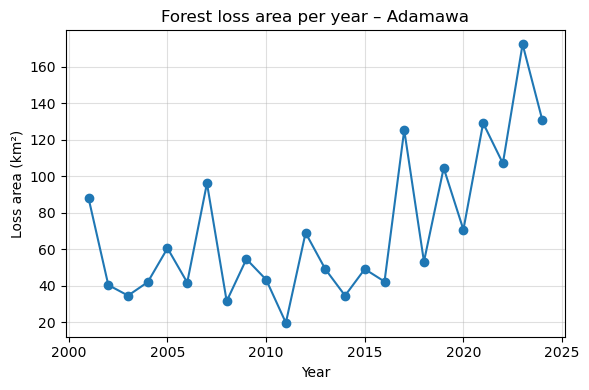

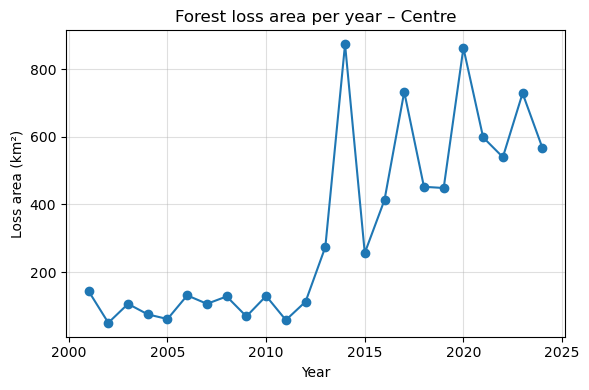

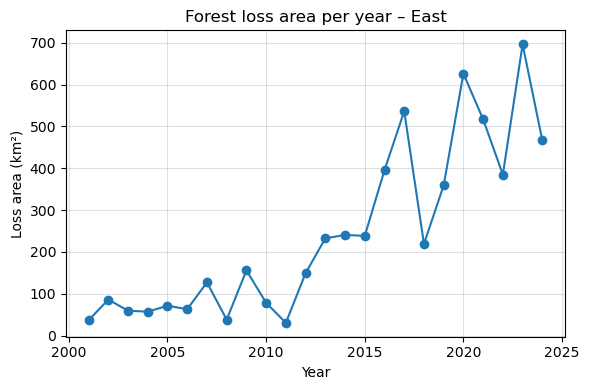

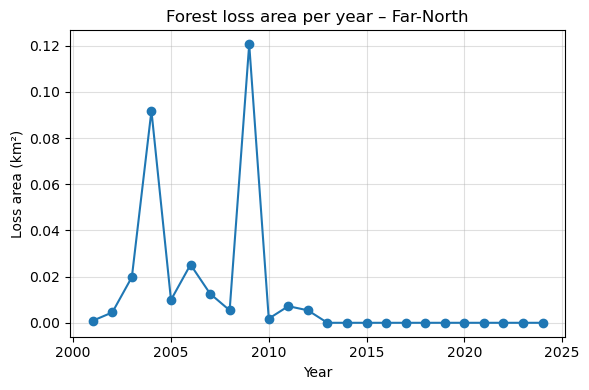

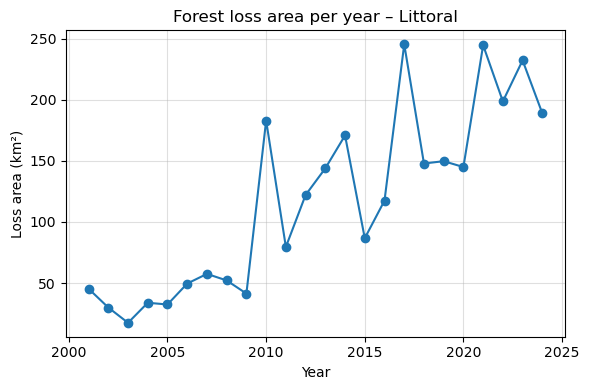

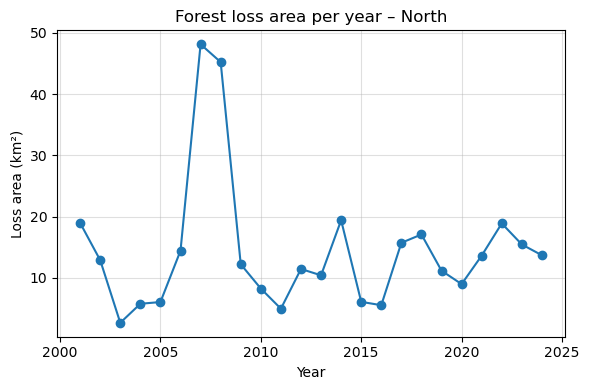

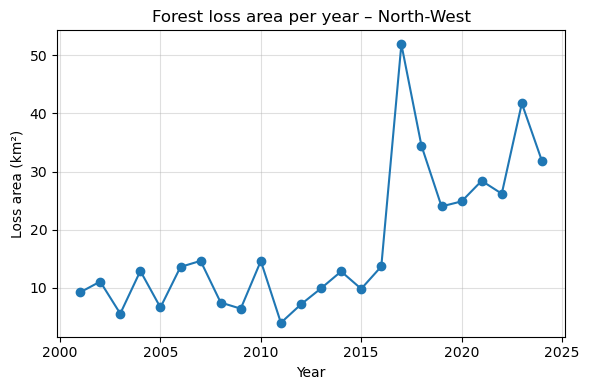

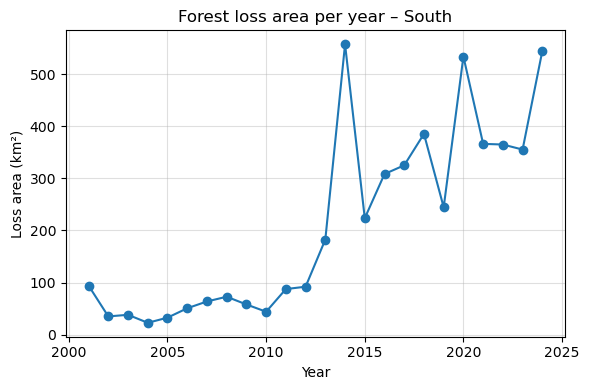

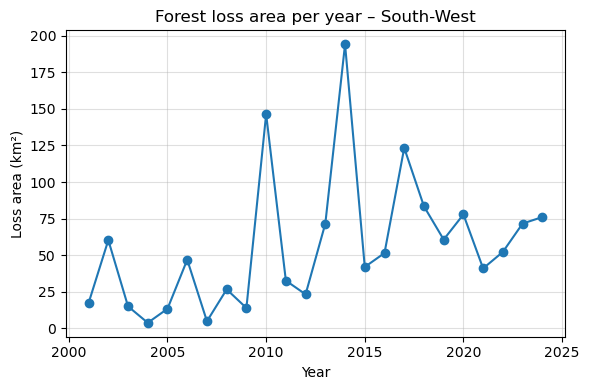

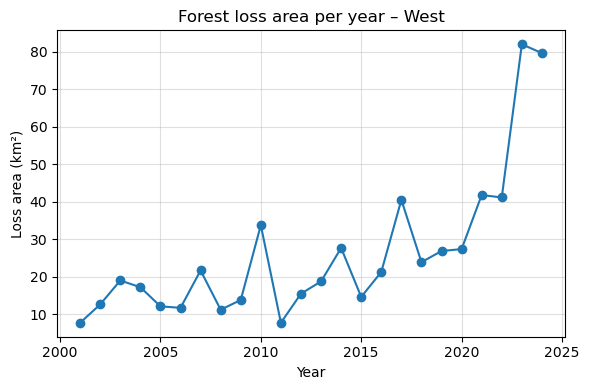

In [46]:
### Step 4.1 – Make 10 line graphs (one per region) ###

regions = sorted(df["region"].unique())

for reg in regions:
    sub = df[df["region"] == reg].sort_values("year")

    # ensure all years 2001–2024 are there (fill missing with 0)
    all_years = pd.DataFrame({"year": range(2001, 2025)})
    sub = all_years.merge(sub, on="year", how="left")
    sub["region"] = sub["region"].fillna(reg)
    sub["loss_area_km2"] = sub["loss_area_km2"].fillna(0)

    plt.figure(figsize=(6, 4))
    plt.plot(sub["year"], sub["loss_area_km2"], marker="o")
    plt.title(f"Forest loss area per year – {reg}")
    plt.xlabel("Year")
    plt.ylabel("Loss area (km²)")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


In [29]:
### Step 5 – Optional: export a summary table ###
summary_csv = out_dir / "cameroon_forest_loss_by_region_year.csv"
df.to_csv(summary_csv, index=False)

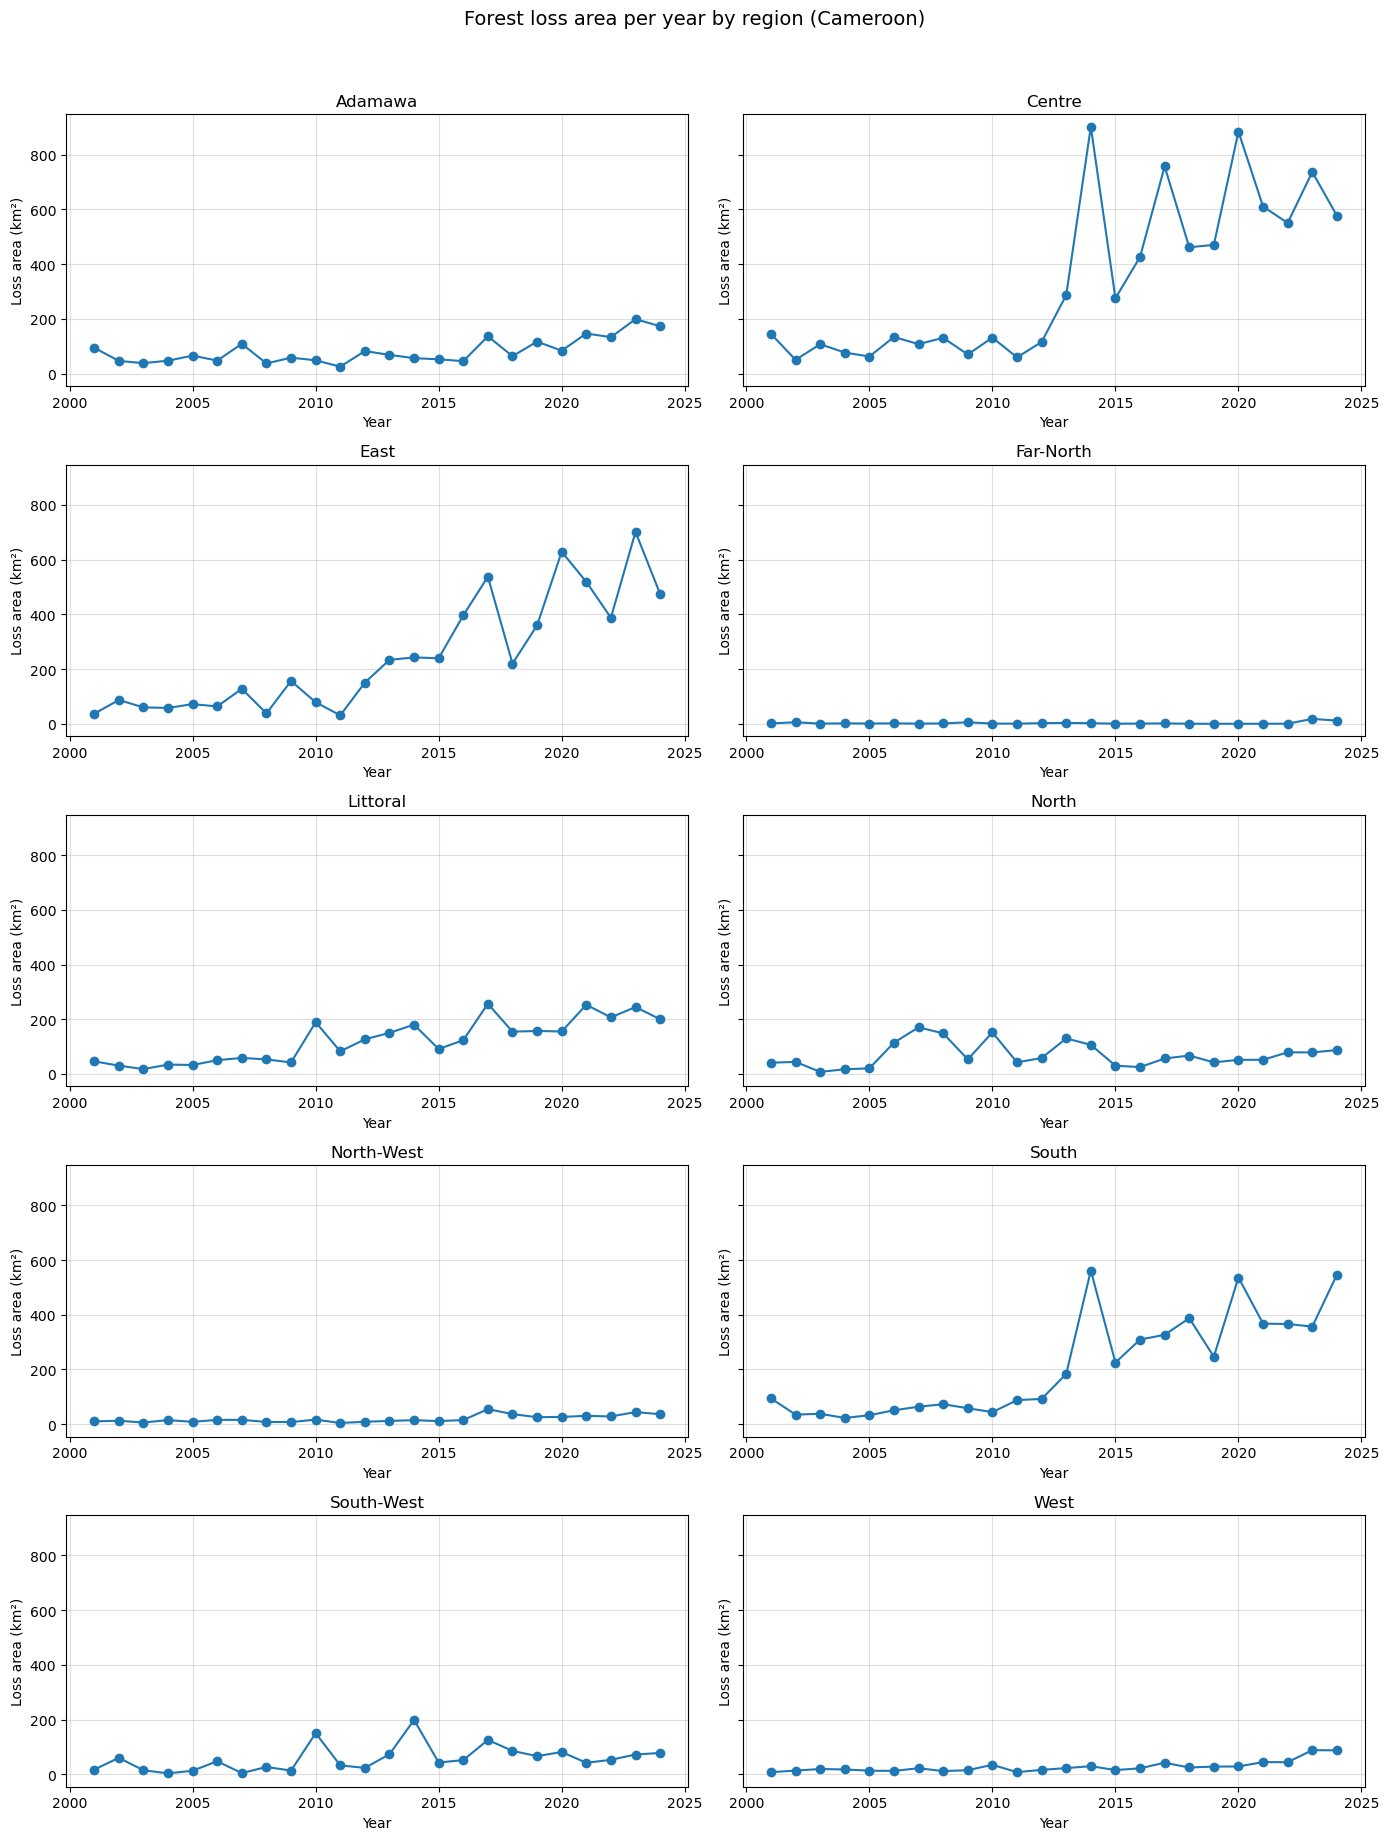

In [25]:
### Step 4.2 – Make a single figure with 10 subplots (5 rows x 2 cols) ###

regions = sorted(df["region"].unique())

fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=False, sharey=True)
axes = axes.flatten()

for ax, reg in zip(axes, regions):
    sub = df[df["region"] == reg].sort_values("year")

    # ensure all years 2001–2024 are there (fill missing with 0)
    sub = all_years.merge(sub, on="year", how="left")
    sub["region"] = sub["region"].fillna(reg)
    sub["loss_area_km2"] = sub["loss_area_km2"].fillna(0)

    ax.plot(sub["year"], sub["loss_area_km2"], marker="o", linewidth=1.5)
    ax.set_title(reg)
    ax.set_xlabel("Year")
    ax.set_ylabel("Loss area (km²)")
    ax.grid(True, alpha=0.4)

plt.suptitle("Forest loss area per year by region (Cameroon)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


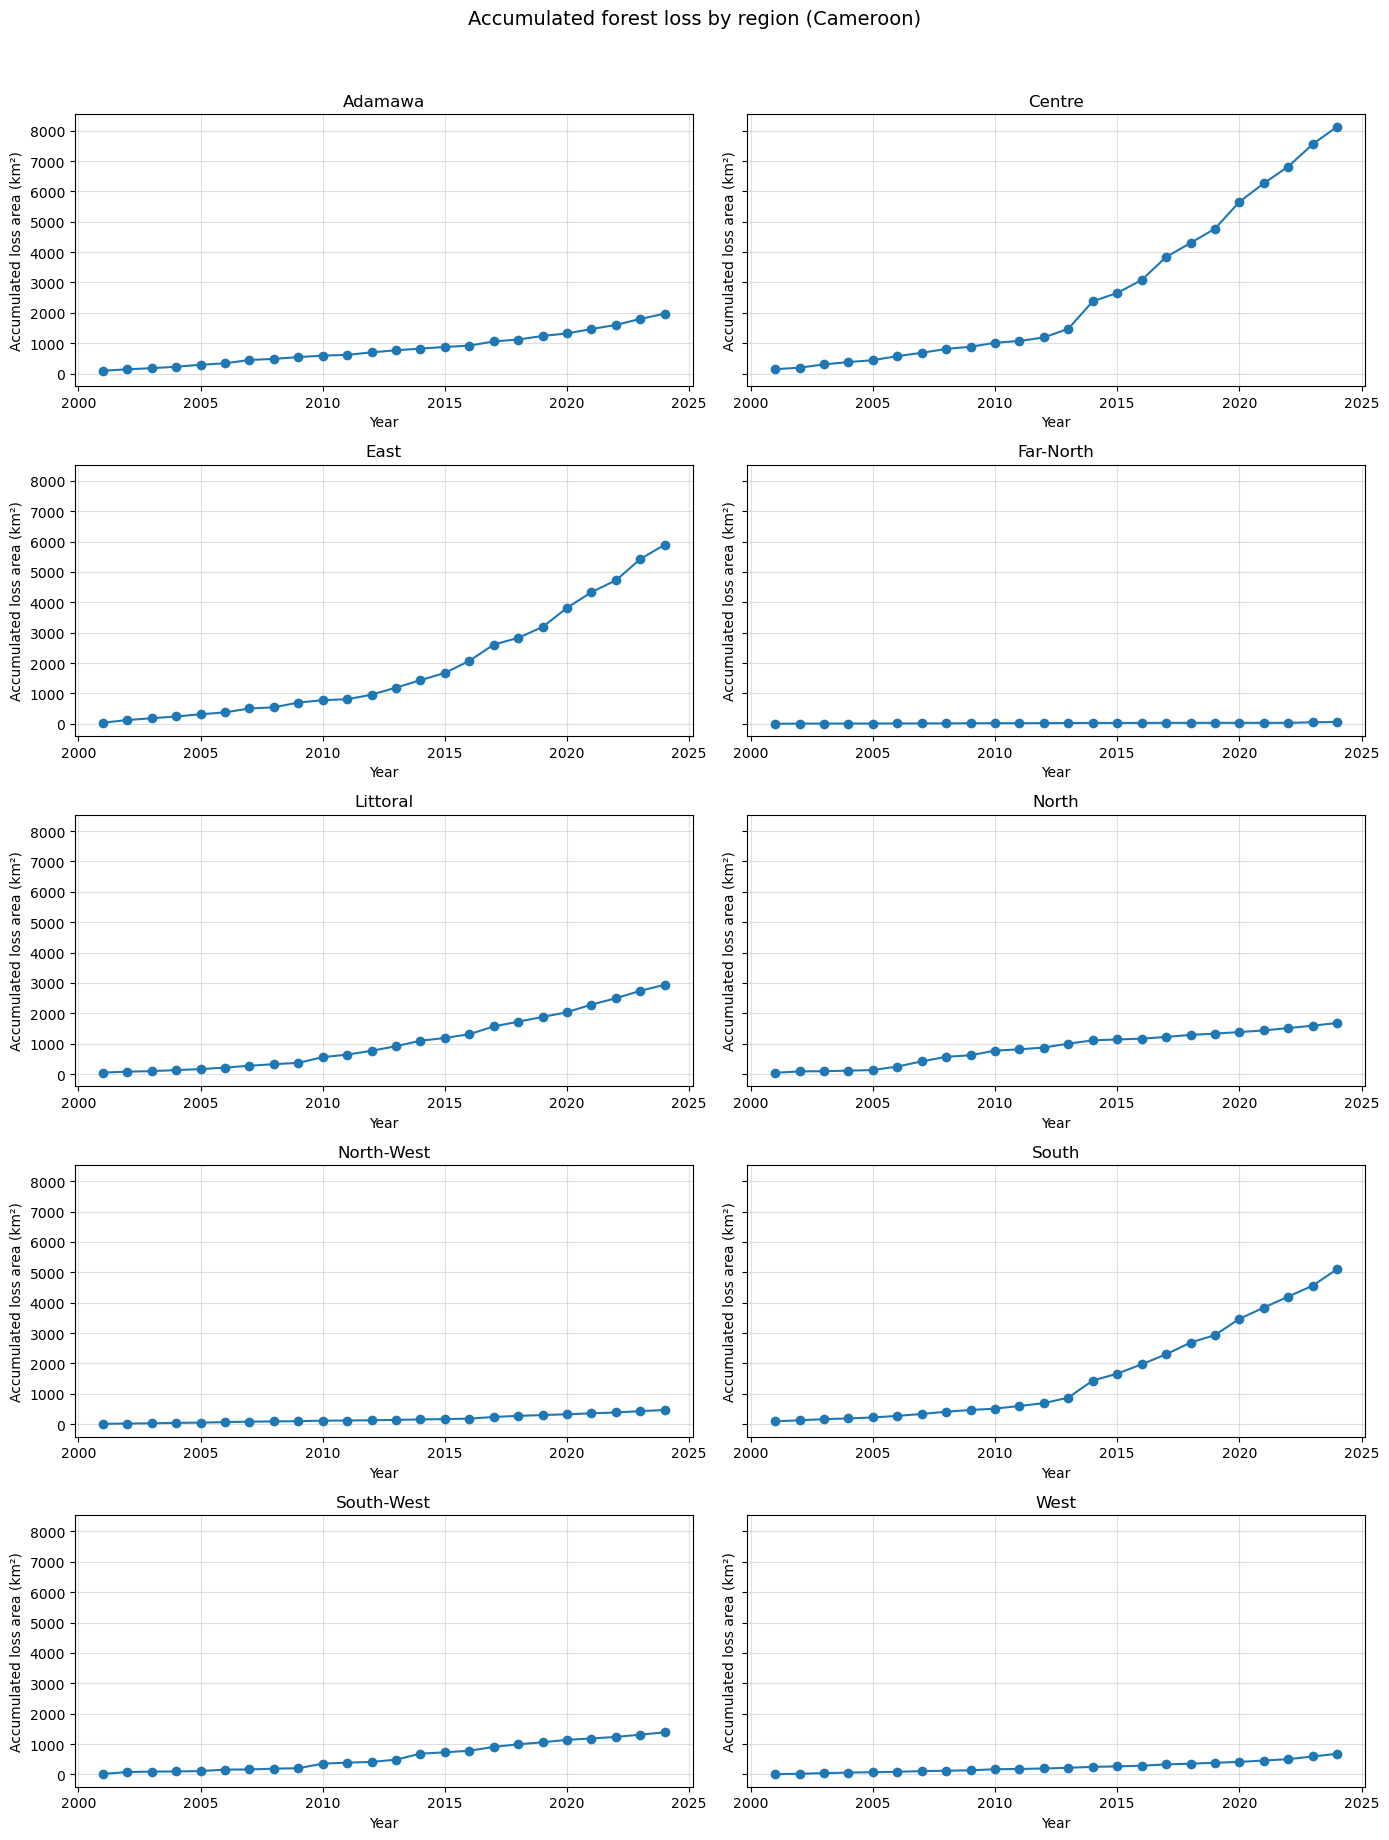

In [27]:
### Step 4.2 – Cummulative Loss Plots ###

regions = sorted(df["region"].unique())

fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=False, sharey=True)
axes = axes.flatten()

for ax, reg in zip(axes, regions):
    sub = df[df["region"] == reg].sort_values("year")

    # ensure all years 2001–2024 are there (fill missing with 0)
    sub = all_years.merge(sub, on="year", how="left")
    sub["region"] = sub["region"].fillna(reg)
    sub["accumulated_loss_area_km2"] = sub["accumulated_loss_area_km2"].fillna(0)

    ax.plot(sub["year"], sub["accumulated_loss_area_km2"], marker="o", linewidth=1.5)
    ax.set_title(reg)
    ax.set_xlabel("Year")
    ax.set_ylabel("Accumulated loss area (km²)")
    ax.grid(True, alpha=0.4)

plt.suptitle("Accumulated forest loss by region (Cameroon)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()
